In [ ]:
import pandas as pd
import re
# ---- NLP ----
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
# ---- Machine Learning ----
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# ---- Save Model ----
import pickle

print("All libraries loaded successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All libraries loaded successfully!


In [ ]:
df=pd.read_csv("spam.csv", encoding="Latin-1")

In [ ]:
df.shape

(5572, 5)

In [ ]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
df=df[['v1','v2']]
df.columns=['label','message']

In [ ]:
df.shape

(5572, 2)

In [ ]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
print(df['label'].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


In [ ]:
print(df['label'].value_counts(normalize=True) * 100)

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


In [ ]:
# Any missing values in our data?
print(df.isnull().sum())

label      0
message    0
dtype: int64


In [ ]:
# First check what the actual values look like
print(df['label'].unique())

['ham' 'spam']


In [ ]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print(df['label'].value_counts())
print(df.head())

label
0    4825
1     747
Name: count, dtype: int64
   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [ ]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

print("Total stopwords:", len(stop_words))

Total stopwords: 198


In [ ]:
def clean_text(message):
    # Step 1: Lowercase
    message = message.lower()

    # Step 2: Remove punctuation and numbers
    message = re.sub('[^a-z]', ' ', message)

    # Step 3: Split into words
    words = message.split()

    # Step 4: Remove stopwords and apply stemming
    words = [ps.stem(word) for word in words if word not in stop_words]

    # Step 5: Join back into a string
    return ' '.join(words)

In [ ]:
# Test on a real spam message from our dataset
sample = df['message'][2]
print("Original:")
print(sample)

print("\nCleaned:")
print(clean_text(sample))

Original:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

Cleaned:
free entri wkli comp win fa cup final tkt st may text fa receiv entri question std txt rate c appli


In [ ]:
df['cleaned'] = df['message'].apply(clean_text)

print("Done!")
print("\nBefore cleaning:")
print(df['message'][2])
print("\nAfter cleaning:")
print(df['cleaned'][2])

Done!

Before cleaning:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

After cleaning:
free entri wkli comp win fa cup final tkt st may text fa receiv entri question std txt rate c appli


In [ ]:
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['cleaned'])
y = df['label']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (5572, 3000)
Shape of y: (5572,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (4457, 3000)
Testing size: (1115, 3000)


In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [ ]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Results:")
print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall   :", recall_score(y_test, y_pred_nb))
print("F1 Score :", f1_score(y_test, y_pred_nb))

Naive Bayes Results:
Accuracy : 0.9757847533632287
Precision: 1.0
Recall   : 0.82
F1 Score : 0.9010989010989011


In [ ]:
y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Results:")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Logistic Regression Results:
Accuracy : 0.9560538116591928
Precision: 0.963302752293578
Recall   : 0.7
F1 Score : 0.8108108108108109


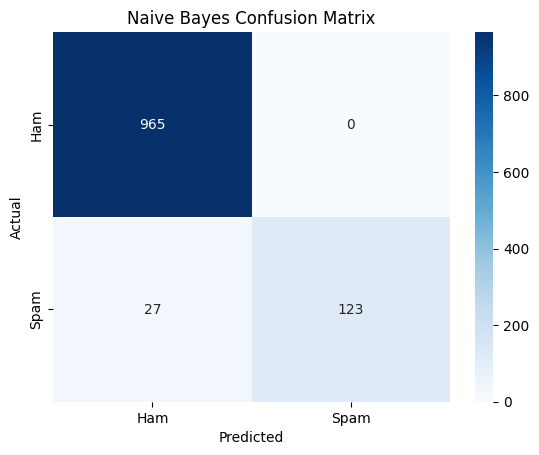

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])

plt.title('Naive Bayes Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
import pickle

# Save Naive Bayes model
with open('spam_model.pkl', 'wb') as f:
    pickle.dump(nb_model, f)

# Save TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Model saved successfully!")
print("Vectorizer saved successfully!")

Model saved successfully!
Vectorizer saved successfully!
